Imoprts

In [1]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans                              

Configuration

In [2]:
DATABASE_PATH = "../data/database.db"

CLUSTER_FEATURES = [
    "transaction_count",
    "avg_transaction_amount",
    "total_spend",
    "avg_session_duration",
    "avg_pages_viewed"
]

RANDOM_STATE = 42
MAX_CLUSTERS = 10

Data Loading

In [3]:
def load_customer_features(db_path: str) -> pd.DataFrame:
    """
    Load customer feature table from SQLite database.
    """
    conn = sqlite3.connect(db_path)
    
    df = pd.read_sql_query(
        "SELECT * FROM customer_features",
        conn
    )
    
    conn.close()
    return df

In [4]:
df = load_customer_features(DATABASE_PATH)
df.head()

,customer_id,age,gender,location,transaction_count,avg_transaction_amount,total_spend,avg_session_duration,avg_pages_viewed
0,1,51,Female,US,10,184.142000,1841.42,22.6400,7.750000
1,2,65,Female,EU,5,171.098000,855.49,11.2200,11.000000
2,3,22,Male,Asia,6,164.463333,986.78,18.6575,9.000000
3,4,22,Male,Asia,3,232.743333,698.23,9.1600,9.333333
4,5,25,Male,EU,8,168.895000,1351.16,7.4820,12.800000


Feature Preparation

In [5]:
def prepare_features(df: pd.DataFrame, features: list):
    """
    Select and scale clustering features.
    """
    
    X = df[features]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, scaler

In [6]:
X_scaled, scaler = prepare_features(df, CLUSTER_FEATURES)

Elbow method to find Optimal Number of clusters:

In [7]:
def plot_elbow_curve(X_scaled, max_clusters=10):
    """
    Plot elbow curve to determine optimal clusters.
    """
    
    inertia = []
    
    for k in range(1, max_clusters):
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE
        )
        
        model.fit(X_scaled)
        inertia.append(model.inertia_)
    
    plt.figure(figsize=(8,5))
    
    plt.plot(range(1, max_clusters), inertia, marker="o")
    
    plt.title("Elbow Method for Optimal Clusters")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    
    plt.show()

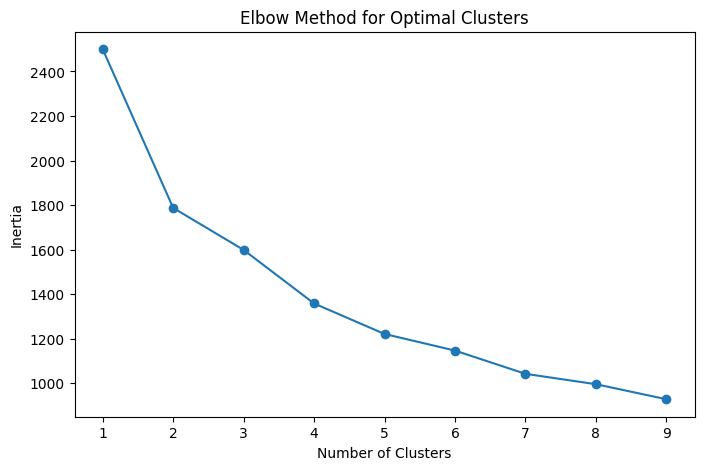

In [8]:
plot_elbow_curve(X_scaled)

##Interpretation:

1–3 clusters: model still learning major structure

4 clusters: captures most structure

>4 clusters: diminishing returns

So the optimal number suggested by the elbow curve is: k = 4 OR n_clusters=4

Clustering Function

In [9]:
def train_kmeans(X_scaled, n_clusters):
    """
    Train KMeans clustering model.
    """
    
    model = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE
    )
    
    clusters = model.fit_predict(X_scaled)
    
    return model, clusters

In [10]:
kmeans_model, clusters = train_kmeans(X_scaled, n_clusters=4)

df["cluster"] = clusters

Visualization

In [11]:
def plot_customer_segments(df):
    """
    Visualize clusters using spend vs engagement.
    """
    
    plt.figure(figsize=(8,6))
    
    sns.scatterplot(
        data=df,
        x="total_spend",
        y="avg_session_duration",
        hue="cluster",
        palette="tab10"
    )
    
    plt.title("Customer Segments")
    plt.xlabel("Total Spend")
    plt.ylabel("Session Duration")
    
    plt.legend(title="Cluster")
    plt.show()

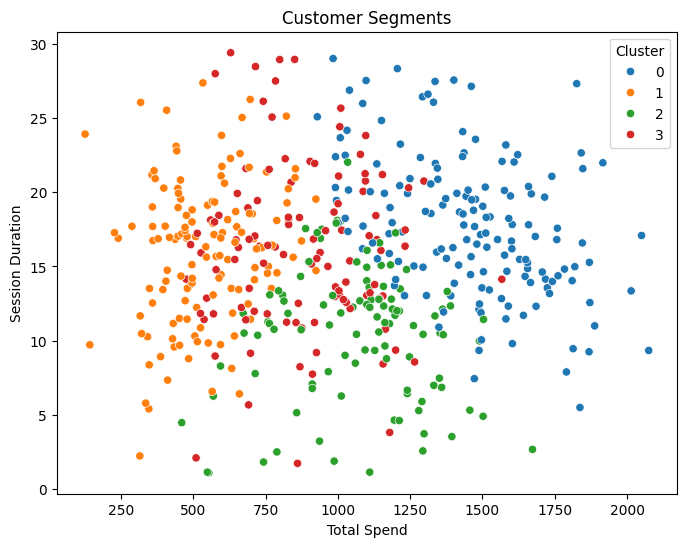

In [12]:
plot_customer_segments(df)

Cluster Analysis:

In [13]:
def analyze_clusters(df, features):
    """
    Show mean feature values per cluster.
    """
    
    summary = df.groupby("cluster")[features].mean()
    
    return summary.round(2)

In [14]:
cluster_summary = analyze_clusters(df, CLUSTER_FEATURES)
cluster_summary

,transaction_count,avg_transaction_amount,total_spend,avg_session_duration,avg_pages_viewed
cluster,,,,,
0,8.80,166.02,1455.41,17.71,10.17
1,4.33,125.72,540.80,16.04,9.33
2,8.03,134.34,1071.56,10.44,11.85
3,4.60,192.47,877.31,16.20,11.52


### Customer Segmentation Insights

Using **K-Means Clustering**, customers were grouped into **four behavioral segments** based on spending patterns, engagement metrics, and transaction behavior.

---

### Cluster 0 — High-Value Loyal Customers

**Characteristics**

* Highest transaction count (~8.8)
* Highest total spending (~1455)
* Long session duration (~17.7 minutes)
* Strong browsing engagement

**Interpretation**

These customers are **highly engaged and frequent buyers**. They contribute significantly to revenue and are likely loyal users of the platform.

**Business Strategy**

* Offer loyalty rewards
* Provide exclusive promotions
* Use personalized recommendations

---

### Cluster 1 — Low-Value Occasional Customers

**Characteristics**

* Lowest transaction count (~4.3)
* Lowest total spending (~540)
* Moderate browsing activity

**Interpretation**

These customers purchase infrequently and generate **low revenue**. They may not yet be fully engaged with the platform.

**Business Strategy**

* Target with discount campaigns
* Introduce onboarding incentives
* Encourage repeat purchases

---

### Cluster 2 — Active Browsers

**Characteristics**

* High transaction count (~8)
* Moderate spending (~1071)
* Lowest session duration (~10.4)
* Highest pages viewed (~11.8)

**Interpretation**

These users **browse a lot but spend moderately**. They are active but may compare products before purchasing.

**Business Strategy**

* Use recommendation systems
* Highlight popular products
* Offer limited-time deals to convert browsing into purchases

---

### Cluster 3 — Premium Buyers

**Characteristics**

* Lower transaction frequency (~4.6)
* Highest average transaction value (~192)
* Moderate total spending (~877)

**Interpretation**

These customers make **fewer purchases but spend more per transaction**. They behave like premium or luxury buyers.

**Business Strategy**

* Promote high-end products
* Offer premium membership tiers
* Provide exclusive product launches

---

### Key Takeaways

The clustering analysis reveals **distinct customer behaviors**, enabling targeted marketing strategies. By identifying high-value users, occasional buyers, and browsing-heavy customers, businesses can design **personalized engagement strategies to improve retention and revenue**.


<Axes: xlabel='pca1', ylabel='pca2'>

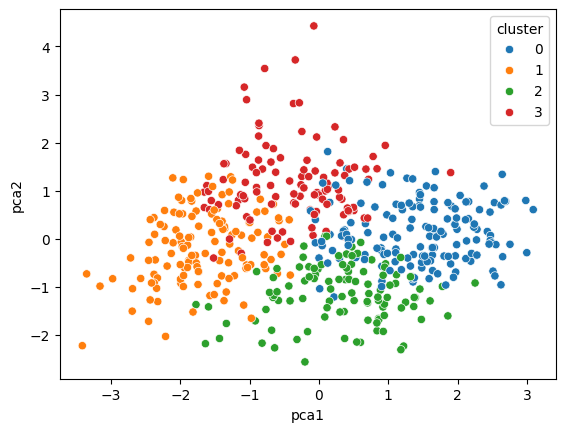

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]

sns.scatterplot(
    data=df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="tab10"
)

In [18]:
def analyze_pca_clusters(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """
    Compute the mean value of each feature for every cluster.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset containing cluster labels.
    features : list
        List of feature columns used in clustering.

    Returns
    -------
    pd.DataFrame
        Cluster summary statistics.
    """

    cluster_summary = (
        df.groupby("cluster")[features]
        .mean()
        .round(2)
        .sort_index()
    )

    return cluster_summary

In [20]:
cluster_summary = analyze_pca_clusters(df, CLUSTER_FEATURES)
print(cluster_summary)

         transaction_count  avg_transaction_amount  total_spend  \
cluster                                                           
0                     8.80                  166.02      1455.41   
1                     4.33                  125.72       540.80   
2                     8.03                  134.34      1071.56   
3                     4.60                  192.47       877.31   

         avg_session_duration  avg_pages_viewed  
cluster                                          
0                       17.71             10.17  
1                       16.04              9.33  
2                       10.44             11.85  
3                       16.20             11.52  


Database Save function

In [21]:
def save_segments_to_db(df: pd.DataFrame, db_path: str):
    """
    Save clustered customer data to SQLite database.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset containing customer clusters.
    db_path : str
        Path to SQLite database.
    """

    with sqlite3.connect(db_path) as conn:
        df.to_sql(
            "customer_segments",
            conn,
            if_exists="replace",
            index=False
        )

    print("Customer segments saved to database.")

In [22]:
save_segments_to_db(df, DATABASE_PATH)

Customer segments saved to database.
